In [1]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ALEJANDRO MELGUIZO
# DATE: 8/18/2026
# TOPIC: new file to filter and clean data for analysis
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
#set working directory
os.chdir("C:/Users/A.Melguizo001/Downloads/Immig, Wages, Latinos")

#preliminary coding
    #defining data frames
df_1 = pd.read_csv('gaston_df_v2.csv')
df_hisp = df_1.copy()

## New var construction

In [3]:
#construcing a new var that measures roughly whether a person got their bachelor's or higher in the US
df_hisp['US_educ'] = 0

hispan_educ_cases = [
    ((df_hisp['educ_clean'] >= 3) & (df_hisp['AGEATIMMIG'] <= 17), 1)
]

df_hisp['US_educ'] = (
    pd.Series(np.nan, index = df_hisp.index)
    .case_when(hispan_educ_cases)
    .fillna(0)
    .astype(int)
)

In [4]:
hispan_race_cases = [
    ((df_hisp['RACE'] == 100), 0), #white
    ((df_hisp['RACE'] == 200), 1), #black
    ((df_hisp['RACE'] == 300), 2), #native american
    ((df_hisp['RACE'].isin(range(650, 653))), 3), #asian / pacific islander
    ((df_hisp['RACE'] == 700), 4),
    ((df_hisp['RACE'].isin(range(801, 831))), 4),
    ((df_hisp['RACE'] == 999), np.nan)
]

df_hisp['race_clean'] = (
    pd.Series(np.nan, index = df_hisp.index)
    .case_when(hispan_race_cases)
    .fillna(np.nan)
    .astype(int)
)

## Data Cleaning

In [14]:
#dropping hisp_clean to re-categorize
df_hisp = df_hisp.drop(columns= ['hisp_clean'])

#re-categorizing hispanic category
hispan_cases = [
    (df_hisp['HISPAN'] == 0, 0),
    ((df_hisp['HISPAN'] >= 100) & (df_hisp['HISPAN'] <= 109), 1),
    (df_hisp['HISPAN'] == 200, 2),
    (df_hisp['HISPAN'] == 300, 3), 
    (df_hisp['HISPAN'] == 400, 4),  #Dominicans
    (df_hisp['HISPAN'] == 500, 5),
    ((df_hisp['HISPAN'] == 610) | (df_hisp['HISPAN'] == 611), 6),
    (df_hisp['HISPAN'] == 612, 7),  #South American
    (df_hisp['HISPAN'] == 600, 8),  #Other Hispanic
    ((df_hisp['HISPAN'].isna()) | (df_hisp['HISPAN'] == 902), 9)    #NA/IDK responses
]

df_hisp['hisp_clean'] = (
    pd.Series(np.nan, index = df_hisp.index)
    .case_when(hispan_cases)
    .fillna(9)
    .astype(int)
)

In [15]:
#filter to only include:

#respondents who are: hispanic, born outside of the US and territories, have data for AGEATIMMIG, and have a non-0 wage.
df_hisp = df_hisp[
    (df_hisp['hisp_clean'] > 0) &
    (df_hisp['hisp_clean'] != 9) &
    (df_hisp['bpl_binary'] == 1) &
    (df_hisp['AGEATIMMIG'].notna()) &
    (df_hisp['incwage_clean'] > 0)
]

#making log wages for regression
df_hisp['log_wage'] = np.log(df_hisp['incwage_clean'])

## non-linear regressors

In [16]:
df_hisp['AAI_sq'] = df_hisp['AGEATIMMIG'] * df_hisp['AGEATIMMIG']

In [17]:

# Massachusetts filter
df_hisp_MA = df_hisp[
    (df_hisp['STATEFIP'] == 25)
]

## Working on Multicollinearity

In [ ]:
import patsy
y, X = patsy.dmatrices("""
log_wage ~ 
AGE +
years_since_immig + 
sex_clean + 
UHRSWORKT + 
US_educ +
sex_clean * C(educ_clean) + 
sex_clean * C(hisp_clean) +
C(CITIZEN) +
C(hisp_clean) + 
C(educ_clean) + 
C(race_clean) + 
C(EMPSTAT) + 
C(STATEFIP)
""",
    data=df_hisp, return_type='dataframe'
)
print(np.linalg.matrix_rank(X), X.shape[1])  # rank < ncols → exact collinearity

92 92


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# columns to check VIF for
X = df_hisp[['AGE', 'years_since_immig', 'sex_clean', 'UHRSWORKT', 'US_educ']]

# create an empty dataframe
vif = pd.DataFrame()

# copy all the features of X in vif dataframe
vif["features"] = X.columns

# calculate VIF for all the variables
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,features,VIF Factor
0,AGE,6.436847
1,years_since_immig,5.757203
2,sex_clean,1.669856
3,UHRSWORKT,1.265308
4,US_educ,1.127306


Text(0.5, 1.0, 'Correlation Matrix')

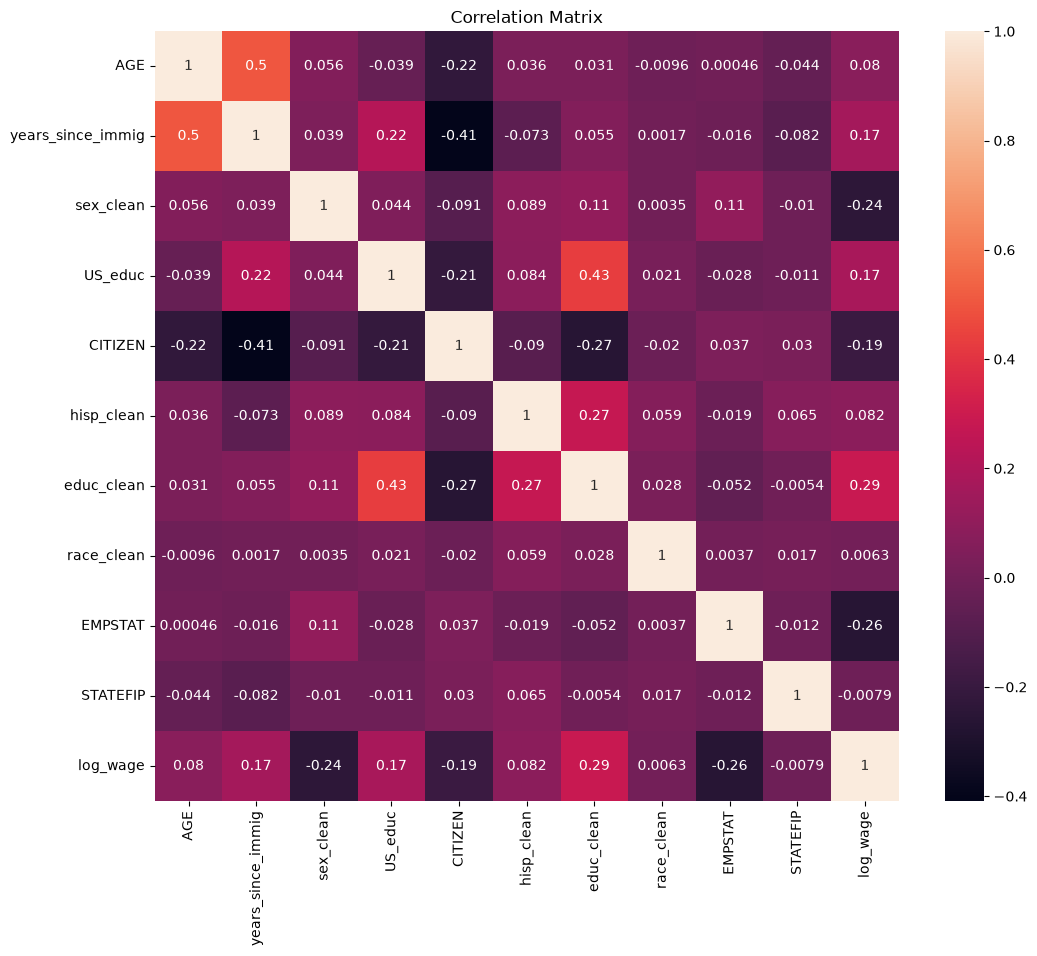

In [10]:
import seaborn as sns

keep_cols = ['AGE', 'years_since_immig', 'sex_clean', 'US_educ', 'CITIZEN', 'hisp_clean', 'educ_clean', 'race_clean', 'EMPSTAT', 'STATEFIP', 'log_wage']

df_filt = df_hisp[keep_cols]

# set figure size
plt.figure(figsize=(12,10))

# plot correlation matrix
sns.heatmap(df_filt.corr(), annot=True)

# set the title
plt.title('Correlation Matrix')

## Download clean csv

In [18]:
#download fully cleaned csv
df_hisp.to_csv('gaston_1.csv', index=False)

df_hisp_MA.to_csv('gaston_1_MA.csv', index=False)